The previous notebooks have been more exploratory, but this notebook will have a higher density of results in it.

Focus will be on extracting knowledge from the diversity patterns in the reference genome, so no direct window-to-window comparisons.

In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

In [2]:
table_desc = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/plots/SupTable_Sample_Stats_wGT_QC_MQ.tsv"
metadata_path = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"

metadata_table = pd.read_csv(table_desc, sep="\t")

metadata_20x_filt = metadata_table.loc[(metadata_table.finalQC != "fail")
                              & (metadata_table.cov_chrA >= 20)
                              & (metadata_table.remove_as_relative != True)
                              & (metadata_table.remove_manual != True)
                              & (~metadata_table.ID.str.startswith("SAMEA11633"))
                             ]

count_sub = metadata_20x_filt.loc[~metadata_20x_filt.cov_chrX.isna()][["gSEX", "group", "species_genotyping", "species"]].value_counts().reset_index()
used_species = count_sub.loc[(count_sub.gSEX == "F") | ((count_sub.gSEX == "M") & (count_sub["count"] >= 2))].species_genotyping.unique()

In [3]:
metadata_20x_filt.family.unique()

array(['Pitheciidae', 'Atelidae', 'Cebidae', 'Aotidae', 'Callitrichidae',
       'Cercopithecidae', 'Hylobatidae', 'Lorisidae', 'Indriidae',
       'Daubentoniidae', 'Lemuridae', 'Galagidae', 'Lepilemuridae',
       'Cheirogaleidae', 'Hominidae', 'Tarsiidae'], dtype=object)

In [4]:
df_l = []
for s in used_species:
    # Read het df
    pi_df_path = "../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)
    if os.path.exists("../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)):
        pi_df = pd.read_csv(pi_df_path, sep="\t")
    else:
        print("Not present:", s)
        continue
    if sum(pi_df.chr_type == "chrX") < 10 or sum(pi_df.chr_type == "aut") < 10:
        print("Too little data", s)
        continue
    df_l.append(pi_df)
all_pi_df = pd.concat(df_l)

In [5]:
species_with_x = all_pi_df.loc[(all_pi_df.chr_type == "chrX") & (~all_pi_df.pi.isna())].species.unique()
len(species_with_x)

192

In [6]:
all_pi_df = all_pi_df.loc[all_pi_df.species.isin(species_with_x)].copy()

In [7]:
chrX_pi = all_pi_df.loc[(all_pi_df.chr_type == "chrX") & (~all_pi_df.pi.isna())]

Determining cutoff for the callable fraction parameter, which determines how large of proportion of the window should be accessible for base calling before passing the filtering step.
Focus is on chrX performance, as the assembly for chromosome X varies more in how good it is.

[Text(0.5, 1.0, 'Callable fraction per species'),
 Text(0.5, 0, 'Callable fraction')]

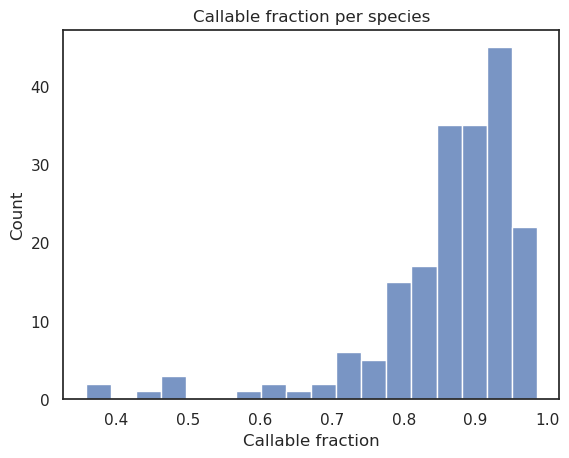

In [8]:
# Most species have a good average callability, but that is actually not the most interesting statistic.
mean_callable = chrX_pi.groupby(["species"])[["callable_frac"]].mean().sort_values(by="callable_frac")
g = sns.histplot(mean_callable, x="callable_frac")
g.set(title="Callable fraction per species", xlabel="Callable fraction")

In [9]:
mean_callable

,callable_frac
species,
Arctocebus_calabarensis_ssp,0.357284
Perodicticus_potto_ssp,0.363138
Lepilemur_septentrionalis_ssp,0.455399
Loris_lydekkerianus_ssp,0.465861
Loris_tardigradus_ssp,0.477096
...,...
Callimico_goeldii_ssp,0.978899
Otolemur_crassicaudatus_ssp,0.981602
Daubentonia_madagascariensis_ssp,0.982396


[Text(0.5, 1.0, 'Callable windows per species'),
 Text(0.5, 0, 'ChrX windows above 75 % callability')]

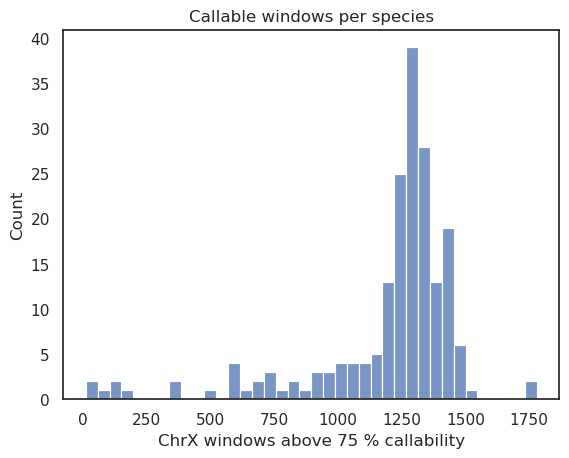

In [10]:
# Instead we can check how many windows pass the filter.
count_callable = chrX_pi.loc[chrX_pi.callable_frac >= 0.75].groupby(["species"])[["callable_frac"]].count().sort_values(by="callable_frac")
g = sns.histplot(count_callable, x="callable_frac")
g.set(title="Callable windows per species", xlabel="ChrX windows above 75 % callability")

[Text(0.5, 1.0, 'Callable windows per species'),
 Text(0.5, 0, 'ChrX windows above 50 % callability')]

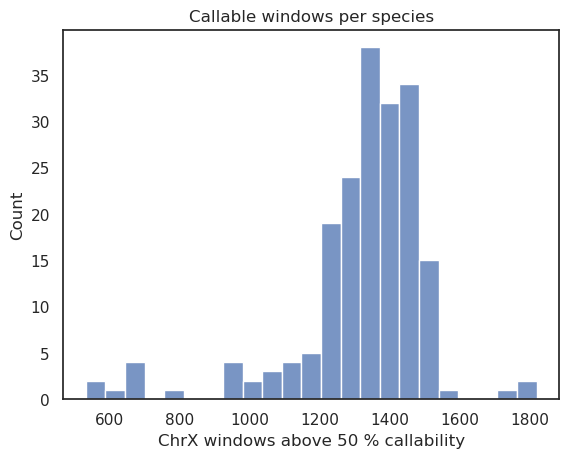

In [11]:
# Allowing for 50 % makes even the worst performers contain roughly 600 windows (or 60Mb).
count_callable = chrX_pi.loc[chrX_pi.callable_frac >= 0.5].groupby(["species"])[["callable_frac"]].count().sort_values(by="callable_frac")
g = sns.histplot(count_callable, x="callable_frac")
g.set(title="Callable windows per species", xlabel="ChrX windows above 50 % callability")

<Axes: xlabel='callable_frac', ylabel='Count'>

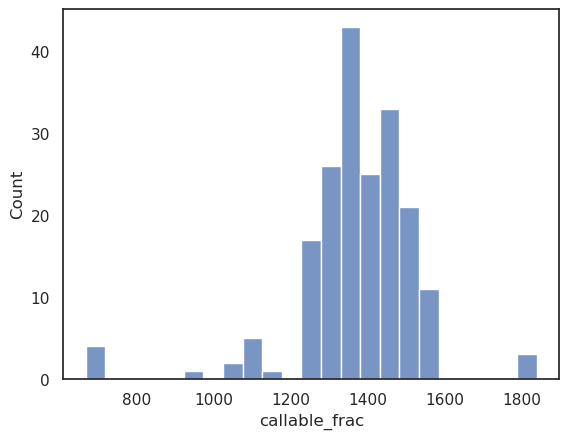

In [12]:
# This is probably too generous, and many of the windows in the 25-50 range will be low quality compared to 50+
count_callable = chrX_pi.loc[chrX_pi.callable_frac >= 0.25].groupby(["species"])[["callable_frac"]].count().sort_values(by="callable_frac")
sns.histplot(count_callable, x="callable_frac")

In [13]:
all_pi_df.chr_type.unique()

array(['aut', 'chrX'], dtype=object)

[Text(0.5, 1.0, 'Relationship between callable windows on autosomes and ChrX'),
 Text(0.5, 0, 'Autosomal windows above 50 % callability'),
 Text(0, 0.5, 'ChrX windows above 50 % callability')]

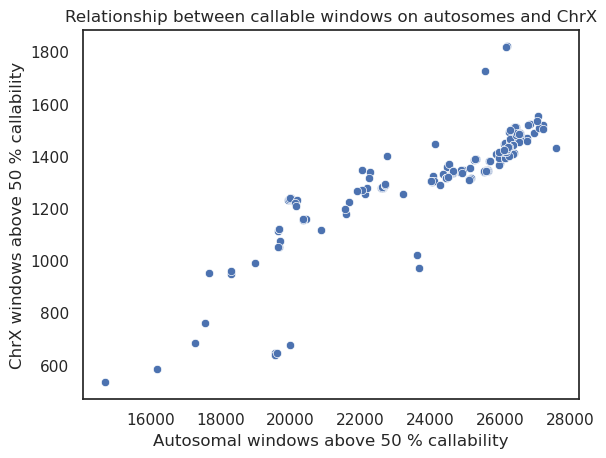

In [14]:
aut_pi = all_pi_df.loc[(all_pi_df.chr_type == "aut") & (~all_pi_df.pi.isna())]
count_callable_chrX = chrX_pi.loc[chrX_pi.callable_frac >= 0.5].groupby(["species"])[["callable_frac"]].count()
count_callable_aut = aut_pi.loc[aut_pi.callable_frac >= 0.5].groupby(["species"])[["callable_frac"]].count()
g = sns.scatterplot(x=count_callable_aut.callable_frac, y=count_callable_chrX.callable_frac)
g.set(title="Relationship between callable windows on autosomes and ChrX",
     xlabel="Autosomal windows above 50 % callability", ylabel="ChrX windows above 50 % callability")

In [15]:
20000*100000

2000000000

In [16]:
count_callable_chrX

,callable_frac
species,
Allenopithecus_nigroviridis_ssp,1323
Allochrocebus_lhoesti_ssp,1448
Allochrocebus_preussi_ssp,1445
Alouatta_belzebul_ssp,1306
Alouatta_discolor_ssp,1299
...,...
Trachypithecus_pileatus_ssp,1417
Trachypithecus_poliocephalus_ssp,1435
Trachypithecus_vetulus_ssp,1424


In [17]:
count_callable_aut

,callable_frac
species,
Allenopithecus_nigroviridis_ssp,24068
Allochrocebus_lhoesti_ssp,26139
Allochrocebus_preussi_ssp,26109
Alouatta_belzebul_ssp,24032
Alouatta_discolor_ssp,24032
...,...
Trachypithecus_pileatus_ssp,25962
Trachypithecus_poliocephalus_ssp,26218
Trachypithecus_vetulus_ssp,26109


In [18]:
# Checking the worst performers.
mean_callable

,callable_frac
species,
Arctocebus_calabarensis_ssp,0.357284
Perodicticus_potto_ssp,0.363138
Lepilemur_septentrionalis_ssp,0.455399
Loris_lydekkerianus_ssp,0.465861
Loris_tardigradus_ssp,0.477096
...,...
Callimico_goeldii_ssp,0.978899
Otolemur_crassicaudatus_ssp,0.981602
Daubentonia_madagascariensis_ssp,0.982396


<Axes: xlabel='callable_frac', ylabel='Count'>

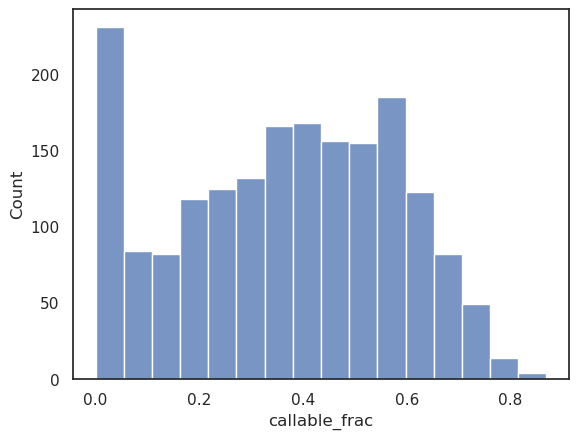

In [19]:
sns.histplot(chrX_pi.loc[chrX_pi.species == "Perodicticus_potto_ssp"], x="callable_frac")

In [20]:
count_callable50 = chrX_pi.loc[chrX_pi.callable_frac >= 0.5].groupby(["species"])[["callable_frac"]].count().sort_values(by="callable_frac")
count_callable50

,callable_frac
species,
Arctocebus_calabarensis_ssp,533
Perodicticus_potto_ssp,583
Hapalemur_meridionalis_ssp,639
Prolemur_simus_ssp,645
Hapalemur_griseus_ssp,646
...,...
Rhinopithecus_roxellana_ssp,1533
Nasalis_larvatus_ssp,1554
Xanthonycticebus_pygmaeus_ssp,1726


In [21]:
species_list = count_callable50.loc[count_callable50.callable_frac >= 200].index
len(species_list)

192

In [22]:
species_list

Index(['Arctocebus_calabarensis_ssp', 'Perodicticus_potto_ssp',
       'Hapalemur_meridionalis_ssp', 'Prolemur_simus_ssp',
       'Hapalemur_griseus_ssp', 'Lemur_catta_ssp',
       'Lepilemur_septentrionalis_ssp', 'Lepilemur_ankaranensis_ssp',
       'Avahi_peyrierasi_ssp', 'Varecia_variegata_ssp',
       ...
       'Hylobates_lar_ssp', 'Macaca_mulatta_ssp', 'Rhinopithecus_strykeri_ssp',
       'Colobus_guereza_ssp', 'Rhinopithecus_bieti_ssp',
       'Rhinopithecus_roxellana_ssp', 'Nasalis_larvatus_ssp',
       'Xanthonycticebus_pygmaeus_ssp', 'Nycticebus_coucang_ssp',
       'Nycticebus_bengalensis_ssp'],
      dtype='object', name='species', length=192)

Removing all windows with less than 50 % callable

In [23]:
filt_pi_df = all_pi_df.loc[all_pi_df.callable_frac >= 0.5]

[Text(0.5, 1.0, 'Mean genetic diversity across species'),
 (-0.0001, 0.007020954500875656),
 (-0.0001, 0.004356546228710463)]

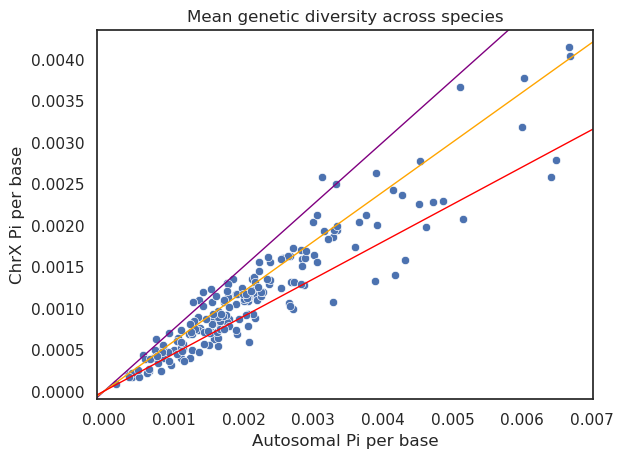

In [24]:
mean_pi_df = filt_pi_df.groupby(["species","chr_type"])[["pi"]].mean()
mean_pi_df = mean_pi_df.reset_index().pivot(columns="chr_type", index="species", values="pi")
mean_pi_df["Autosomal Pi per base"] = mean_pi_df.aut/100000
mean_pi_df["ChrX Pi per base"] = mean_pi_df.chrX/100000
mean_pi_df["X_a_ratio"] = mean_pi_df.chrX/mean_pi_df.aut
mean_pi_df["X/A ratio"] = mean_pi_df.chrX/mean_pi_df.aut
mean_pi_df = mean_pi_df.reset_index()
plt.axline((0, 0), slope=0.75, linewidth=1, color='purple')
plt.axline((0, 0), slope=0.6, linewidth=1, color='orange')
plt.axline((0, 0), slope=0.45, linewidth=1, color='red')
g = sns.scatterplot(mean_pi_df, x="Autosomal Pi per base", y="ChrX Pi per base")
g.set(title="Mean genetic diversity across species", xlim=(-0.0001, None), ylim=(-0.0001, None))

[Text(0.5, 1.0, 'Mean genetic diversity across species'),
 (-0.0001, 0.007020954500875656),
 (-0.0001, 0.004356546228710463)]

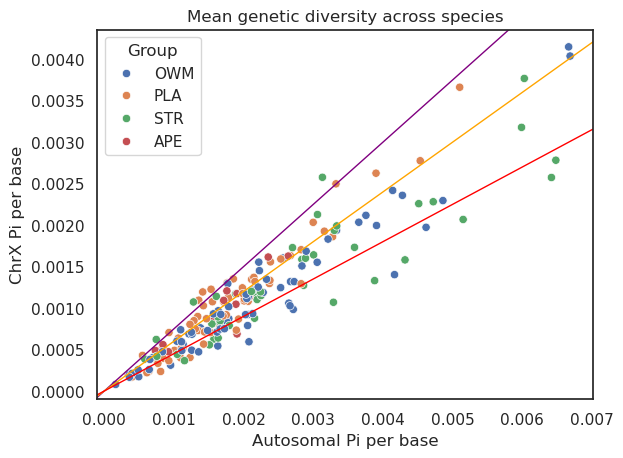

In [25]:
mean_pi_df["Group"] = mean_pi_df.species.map(dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group)))
plt.axline((0, 0), slope=0.75, linewidth=1, color='purple')
plt.axline((0, 0), slope=0.6, linewidth=1, color='orange')
plt.axline((0, 0), slope=0.45, linewidth=1, color='red')
g = sns.scatterplot(mean_pi_df, x="Autosomal Pi per base", y="ChrX Pi per base", hue="Group")
g.set(title="Mean genetic diversity across species", xlim=(-0.0001, None), ylim=(-0.0001, None))

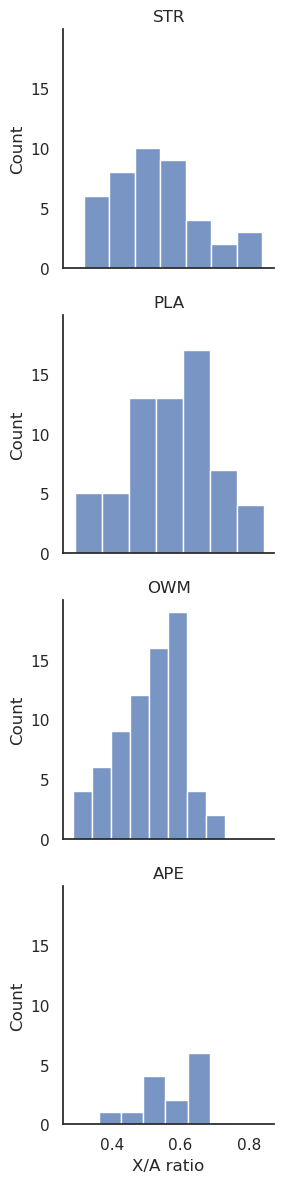

In [26]:
mean_pi_df["Group"] = mean_pi_df.species.map(dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group)))
g = sns.FacetGrid(mean_pi_df.loc[mean_pi_df.Group.isin(["OWM", "PLA", "STR", "APE"])].sort_values(by="Group", ascending=False), col="Group",  col_wrap = 1)
g.map_dataframe(sns.histplot, x="X/A ratio", common_norm=False)
g.set_titles(col_template="{col_name}")

In [27]:
mean_pi_df.groupby(["Group"])["X/A ratio"].median()

Group
APE    0.616347
OWM    0.534201
PLA    0.588908
STR    0.517095
Name: X/A ratio, dtype: float64

In [28]:
# Kruskal-Wallis H-test
APE = mean_pi_df.loc[mean_pi_df.Group == "APE"]["X/A ratio"]
OWM = mean_pi_df.loc[mean_pi_df.Group == "OWM"]["X/A ratio"]
PLA = mean_pi_df.loc[mean_pi_df.Group == "PLA"]["X/A ratio"]
STR = mean_pi_df.loc[(mean_pi_df.Group == "STR") & ~(mean_pi_df.chrX.isna())]["X/A ratio"]
from scipy import stats
from scipy.stats import f_oneway
F = stats.kruskal(APE, OWM, PLA, STR, nan_policy="omit")
F

KruskalResult(statistic=13.462633694048805, pvalue=0.0037358208773635893)

In [29]:
from scipy.stats import tukey_hsd
print(tukey_hsd(APE, OWM, PLA, STR))

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.073     0.125    -0.013     0.159
 (0 - 2)      0.012     0.982    -0.074     0.099
 (0 - 3)      0.060     0.323    -0.031     0.151
 (1 - 0)     -0.073     0.125    -0.159     0.013
 (1 - 2)     -0.061     0.011    -0.111    -0.010
 (1 - 3)     -0.013     0.930    -0.071     0.044
 (2 - 0)     -0.012     0.982    -0.099     0.074
 (2 - 1)      0.061     0.011     0.010     0.111
 (2 - 3)      0.047     0.157    -0.011     0.106
 (3 - 0)     -0.060     0.323    -0.151     0.031
 (3 - 1)      0.013     0.930    -0.044     0.071
 (3 - 2)     -0.047     0.157    -0.106     0.011



In [30]:
mean_pi_df.groupby(["Group"])["aut"].median()

Group
APE    173.702823
OWM    190.703713
PLA    154.381635
STR    224.647775
Name: aut, dtype: float64

In [31]:
# Kruskal-Wallis H-test for autosomal diversity
APE = mean_pi_df.loc[mean_pi_df.Group == "APE"]["aut"]
OWM = mean_pi_df.loc[mean_pi_df.Group == "OWM"]["aut"]
PLA = mean_pi_df.loc[mean_pi_df.Group == "PLA"]["aut"]
STR = mean_pi_df.loc[mean_pi_df.Group == "STR"]["aut"]
from scipy import stats
from scipy.stats import f_oneway
F = stats.kruskal(APE, OWM, PLA, STR, nan_policy="omit")
F

KruskalResult(statistic=14.85084993626117, pvalue=0.0019486473786282997)

In [32]:
from scipy.stats import tukey_hsd
print(tukey_hsd(APE, OWM, PLA, STR))

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)    -52.382     0.469  -145.878    41.115
 (0 - 2)    -18.296     0.958  -112.739    76.146
 (0 - 3)   -118.856     0.011  -217.638   -20.073
 (1 - 0)     52.382     0.469   -41.115   145.878
 (1 - 2)     34.085     0.377   -20.905    89.076
 (1 - 3)    -66.474     0.031  -128.624    -4.325
 (2 - 0)     18.296     0.958   -76.146   112.739
 (2 - 1)    -34.085     0.377   -89.076    20.905
 (2 - 3)   -100.560     0.000  -164.124   -36.995
 (3 - 0)    118.856     0.011    20.073   217.638
 (3 - 1)     66.474     0.031     4.325   128.624
 (3 - 2)    100.560     0.000    36.995   164.124



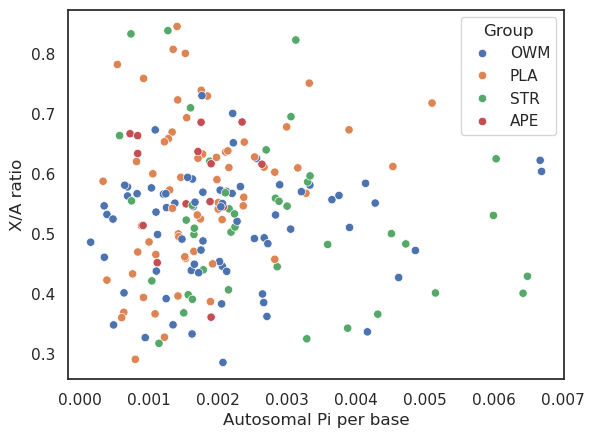

In [33]:
g = sns.scatterplot(mean_pi_df, x="Autosomal Pi per base", y="X/A ratio", hue="Group")

In [34]:
filt_pi_df_aut = filt_pi_df.loc[filt_pi_df.chr_type == "aut"]
filt_pi_df_chrx = filt_pi_df.loc[filt_pi_df.chr_type == "chrX"]
mean_pi_df = mean_pi_df.reset_index()
mean_pi_df["CV_aut"] = (filt_pi_df_aut.groupby(["species"])[["pi"]].std() / filt_pi_df_aut.groupby(["species"])[["pi"]].mean()).reset_index()["pi"]
mean_pi_df["CV_x"] = (filt_pi_df_chrx.groupby(["species"])[["pi"]].std() / filt_pi_df_chrx.groupby(["species"])[["pi"]].mean()).reset_index()["pi"]

[Text(0.5, 0, 'CV of autosomes'),
 Text(0, 0.5, 'CV of chromosome X'),
 (0.0, 2.748117374275374),
 (0.0, 4.034580709774808),
 Text(0.5, 1.0, 'Relationship between coefficients of variation')]

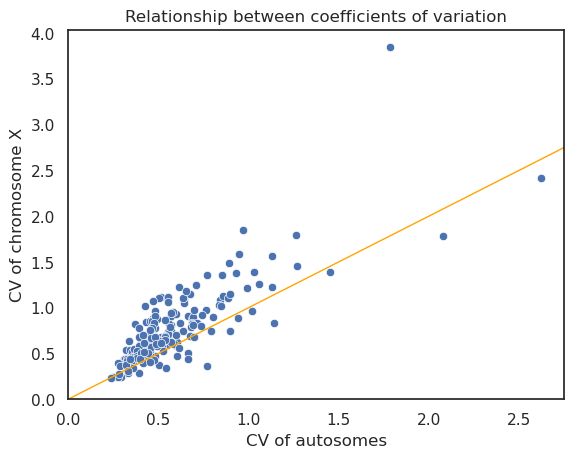

In [35]:
g = sns.scatterplot(mean_pi_df, x="CV_aut", y="CV_x")
plt.axline((0, 0), slope=1, linewidth=1, color='orange')
g.set(xlabel = "CV of autosomes", ylabel="CV of chromosome X", xlim=(0, None), ylim=(0, None),
      title="Relationship between coefficients of variation")

[Text(0.5, 0, 'CV of chromosome X'), Text(0, 0.5, 'X/A ratio')]

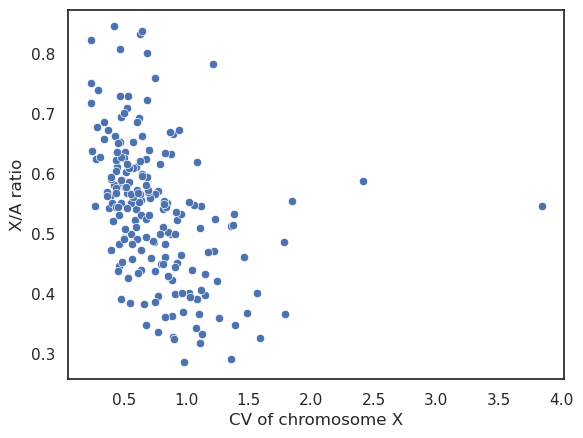

In [36]:
g = sns.scatterplot(mean_pi_df, y="X_a_ratio", x="CV_x")
g.set(xlabel = "CV of chromosome X", ylabel="X/A ratio")

[Text(0.5, 0, 'Autosomal Pi per base'), Text(0, 0.5, 'CV of autosomes')]

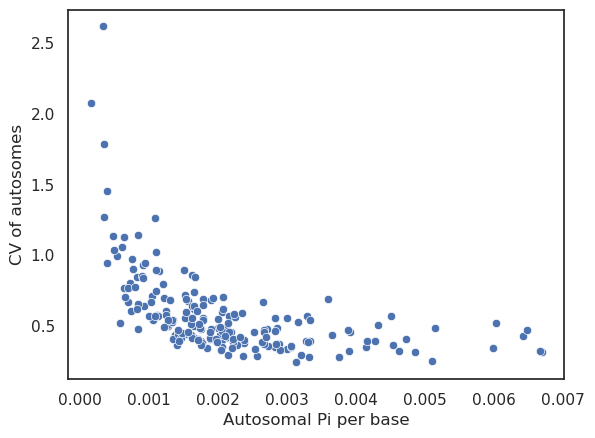

In [37]:
g = sns.scatterplot(mean_pi_df, x="Autosomal Pi per base", y="CV_aut")
g.set(xlabel = "Autosomal Pi per base", ylabel="CV of autosomes")

[Text(0.5, 0, 'ChrX Pi per base'), Text(0, 0.5, 'CV of chrX')]

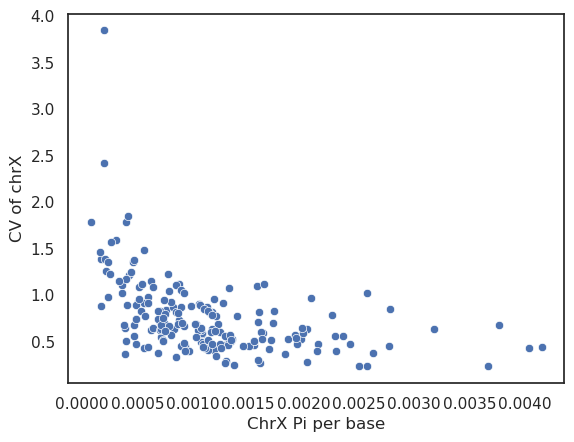

In [38]:
g = sns.scatterplot(mean_pi_df, x="ChrX Pi per base", y="CV_x")
g.set(xlabel = "ChrX Pi per base", ylabel="CV of chrX")

In [39]:
mean_pi_df["CV per diversity on chrX"] = mean_pi_df["CV_x"]/mean_pi_df["chrX"]
mean_pi_df["CV per diversity on autosomes"] = mean_pi_df["CV_aut"]/mean_pi_df["aut"]

<Axes: xlabel='CV per diversity on autosomes', ylabel='CV per diversity on chrX'>

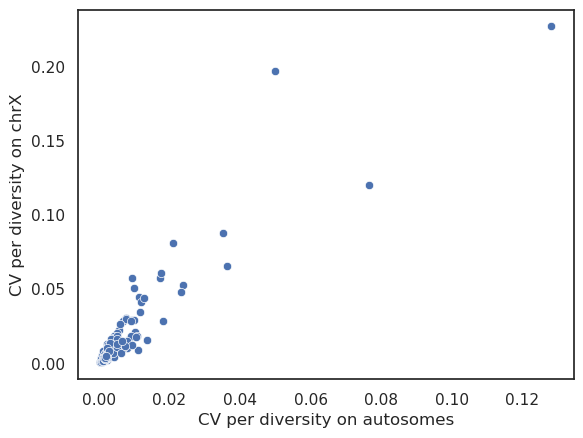

In [40]:
sns.scatterplot(mean_pi_df, x="CV per diversity on autosomes", y="CV per diversity on chrX")

In [41]:
mean_pi_df.loc[(mean_pi_df.aut > 100) & (mean_pi_df.aut < 200)].CV_aut.mean()

0.567554420481712

In [42]:
mean_pi_df.loc[(mean_pi_df.chrX > 100) & (mean_pi_df.chrX < 200)].CV_x.mean()

0.5973753652872015

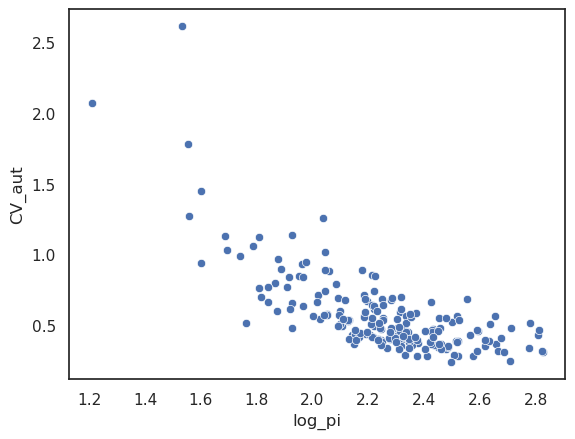

In [43]:
mean_pi_df["log_pi"] = np.log10(mean_pi_df["aut"])
g = sns.scatterplot(mean_pi_df, x="log_pi", y="CV_aut")

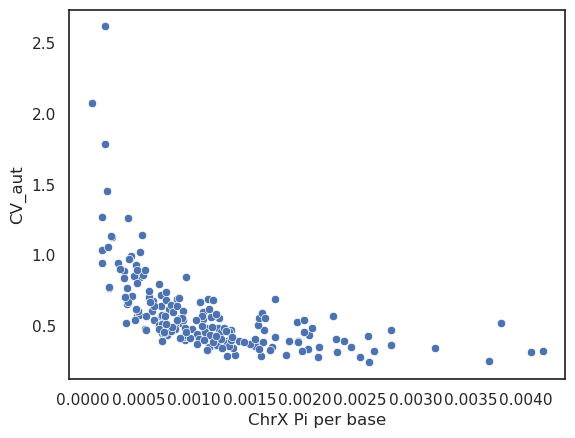

In [44]:
g = sns.scatterplot(mean_pi_df, x="ChrX Pi per base", y="CV_aut")

<Axes: xlabel='CV_aut', ylabel='Count'>

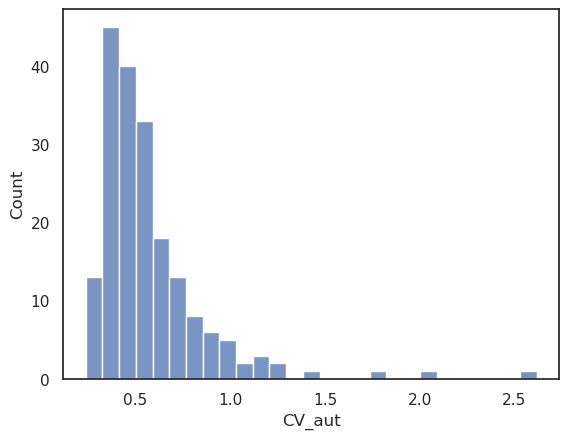

In [45]:
sns.histplot(mean_pi_df, x="CV_aut")

<Axes: xlabel='CV_x', ylabel='Count'>

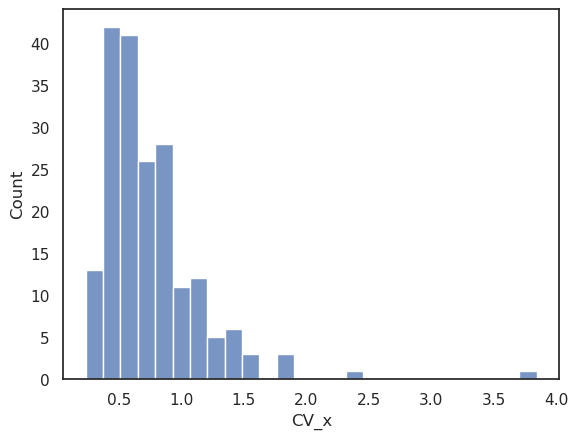

In [46]:
sns.histplot(mean_pi_df, x="CV_x")

[Text(0.5, 0, 'ChrX CV - autosomal CV')]

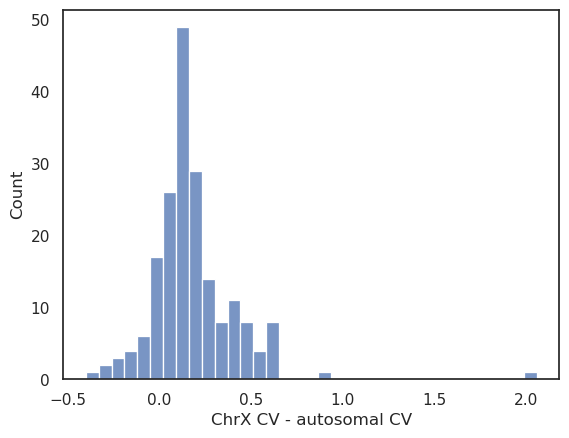

In [47]:
mean_pi_df["CV_difference"] = mean_pi_df.CV_x-mean_pi_df.CV_aut
g = sns.histplot(mean_pi_df, x="CV_difference")
g.set(xlabel="ChrX CV - autosomal CV")

In [48]:
mean_pi_df

chr_type,index,species,aut,chrX,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,Group,CV_aut,CV_x,CV per diversity on chrX,CV per diversity on autosomes,log_pi,CV_difference
0,0,Allenopithecus_nigroviridis_ssp,138.049579,76.072058,0.001380,0.000761,0.551049,0.551049,OWM,0.429124,0.842548,0.011076,0.003108,2.140035,0.413424
1,1,Allochrocebus_lhoesti_ssp,271.244663,98.289917,0.002712,0.000983,0.362366,0.362366,OWM,0.471371,0.883453,0.008988,0.001738,2.433361,0.412082
2,2,Allochrocebus_preussi_ssp,264.850665,105.876125,0.002649,0.001059,0.399758,0.399758,OWM,0.663639,0.907065,0.008567,0.002506,2.423001,0.243427
3,3,Alouatta_belzebul_ssp,510.169378,366.218989,0.005102,0.003662,0.717838,0.717838,PLA,0.249125,0.238095,0.000650,0.000488,2.707714,-0.011030
4,4,Alouatta_discolor_ssp,206.429698,108.086733,0.002064,0.001081,0.523601,0.523601,PLA,0.591447,0.587333,0.005434,0.002865,2.314772,-0.004113
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,187,Trachypithecus_pileatus_ssp,110.758378,59.386733,0.001108,0.000594,0.536183,0.536183,OWM,0.744030,0.915198,0.015411,0.006718,2.044377,0.171168
188,188,Trachypithecus_poliocephalus_ssp,65.467857,38.032207,0.000655,0.000380,0.580929,0.580929,OWM,0.698364,0.678975,0.017853,0.010667,1.816028,-0.019388
189,189,Trachypithecus_vetulus_ssp,232.827177,134.729050,0.002328,0.001347,0.578665,0.578665,OWM,0.418915,0.515573,0.003827,0.001799,2.367034,0.096657
190,190,Varecia_variegata_ssp,211.144432,120.002801,0.002111,0.001200,0.568345,0.568345,STR,0.421419,0.614303,0.005119,0.001996,2.324580,0.192884


In [49]:
mean_pi_df.CV_aut.mean(), mean_pi_df.CV_x.mean(), mean_pi_df.CV_difference.mean()

(0.5736749592906555, 0.755573527220025, 0.18189856792936965)

In [50]:
import numpy as np
from scipy import stats
diff_df = mean_pi_df.loc[~mean_pi_df.CV_difference.isna()]
stats.ttest_rel(diff_df.CV_aut, diff_df.CV_x)

TtestResult(statistic=-10.584724426692398, pvalue=6.746856052171312e-21, df=191)

In [51]:
mean_per_chrom = filt_pi_df.groupby(["species", "chr_type", "chrom"])["pi"].mean().reset_index()

In [52]:
filt_pi_df.loc[filt_pi_df.species == "Gorilla_gorilla_ssp"].groupby(["species", "chrom", "chr_type"])["pi"].apply(lambda x: x.autocorr(lag=1)).reset_index()

,species,chrom,chr_type,pi
0,Gorilla_gorilla_ssp,NC_073224.2,aut,0.603243
1,Gorilla_gorilla_ssp,NC_073227.2,aut,0.599215
2,Gorilla_gorilla_ssp,NC_073228.2,aut,0.636907
3,Gorilla_gorilla_ssp,NC_073229.2,aut,0.493563
4,Gorilla_gorilla_ssp,NC_073230.2,aut,0.675003
5,Gorilla_gorilla_ssp,NC_073231.2,aut,0.662505
6,Gorilla_gorilla_ssp,NC_073232.2,aut,0.679510
7,Gorilla_gorilla_ssp,NC_073233.2,aut,0.677812
8,Gorilla_gorilla_ssp,NC_073234.2,aut,0.589811
9,Gorilla_gorilla_ssp,NC_073235.2,aut,0.705807


In [53]:
s_l, aut_corr_l, x_corr_l = [], [], []
for species in filt_pi_df.species.unique():
    chrom_corr = filt_pi_df.loc[filt_pi_df.species == species].groupby(["species", "chrom", "chr_type"])["pi"].apply(lambda x: x.autocorr(lag=1)).reset_index()
    chrom_corr = chrom_corr.loc[~chrom_corr["pi"].isna()]
    s_l.append(species)
    aut_corr_l.append(chrom_corr.loc[chrom_corr.chr_type == "aut"]["pi"].mean())
    x_corr_l.append(chrom_corr.loc[chrom_corr.chr_type == "chrX"]["pi"].mean())

/home/eriks/miniconda3/envs/primatediversity2/lib/python3.12/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/eriks/miniconda3/envs/primatediversity2/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/eriks/miniconda3/envs/primatediversity2/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/home/eriks/miniconda3/envs/primatediversity2/lib/python3.12/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/eriks/miniconda3/envs/primatediversity2/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/eriks/miniconda3/envs/prima

In [54]:
corr_df = pd.DataFrame({"species": s_l, "Mean_aut_corr": aut_corr_l, "Mean_x_corr": x_corr_l})
stats.ttest_rel(corr_df.Mean_aut_corr, corr_df.Mean_x_corr)

TtestResult(statistic=-9.81380399572815, pvalue=1.1479460807088665e-18, df=191)

In [80]:
corr_df[["Mean_aut_corr", "Mean_x_corr"]].mean()

Mean_aut_corr    0.479743
Mean_x_corr      0.567443
dtype: float64

[Text(0.5, 1.0, 'Autocorrelation across autosomes and chromosome X'),
 Text(0.5, 0, 'Mean autosomal autocorrelation'),
 Text(0, 0.5, 'Mean chromosome X autocorrelation')]

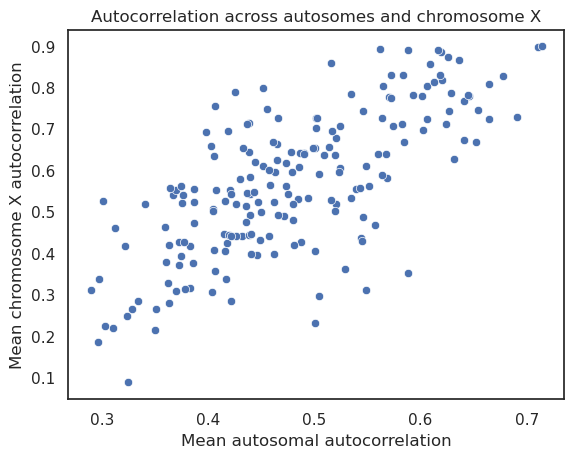

In [77]:
g = sns.scatterplot(corr_df, x="Mean_aut_corr", y="Mean_x_corr")
g.set(title="Autocorrelation across autosomes and chromosome X", xlabel="Mean autosomal autocorrelation",
     ylabel="Mean chromosome X autocorrelation")

In [55]:
corr_df.loc[~corr_df.Mean_x_corr.isna()]

,species,Mean_aut_corr,Mean_x_corr
0,Macaca_fascicularis_ssp,0.677799,0.828089
1,Pan_troglodytes_ssp,0.545963,0.741969
2,Papio_anubis_ssp,0.546070,0.486424
3,Macaca_mulatta_ssp,0.628231,0.785624
4,Macaca_fuscata_ssp,0.418963,0.694820
...,...,...,...
187,Presbytis_comata_ssp,0.362691,0.418516
188,Presbytis_melalophos_ssp,0.439976,0.446522
189,Miopithecus_ogouensis_ssp,0.321458,0.416449
190,Semnopithecus_priam_ssp,0.504668,0.296943


In [56]:
# Credit to Vasili Pankratov for consolidating this data
mating_vas = pd.read_excel("../data/PrimatePhenotypes_december.xlsx", sheet_name=8)
mating_vas

,binomial_name,Monogamous,Polygynous,Polygynandrous,Polyandrous,lowSC,highSC,consensus,comment,Juliana_Christina,genus_comment
0,Allenopithecus_nigroviridis,0,0,1,0,0,1,Polygynandrous,NaN,NaN,NaN
1,Allocebus_trichotis,2,1,0,0,3,0,Monogamous,NaN,NaN,NaN
2,Allochrocebus_lhoesti,0,3,0,0,3,0,Polygynous,NaN,NaN,NaN
3,Allochrocebus_preussi,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN
4,Allochrocebus_solatus,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
311,Trachypithecus_phayrei,0,2,1,0,2,1,NaN,conflicting,NaN,NaN
312,Trachypithecus_pileatus,0,2,0,0,2,0,Polygynous,NaN,NaN,NaN
313,Trachypithecus_selangorensis,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN
314,Varecia_rubra,0,1,1,0,1,1,NaN,conflicting,NaN,NaN


In [57]:
mean_pi_df = filt_pi_df.loc[(filt_pi_df.species.isin(species_list))].groupby(["species","chr_type"])[["pi"]].mean()
mean_pi_df = mean_pi_df.reset_index().pivot(columns="chr_type", index="species", values="pi")
mean_pi_df["Autosomal Pi per base"] = mean_pi_df.aut/100000
mean_pi_df["ChrX Pi per base"] = mean_pi_df.chrX/100000
mean_pi_df["X_a_ratio"] = mean_pi_df.chrX/mean_pi_df.aut
mean_pi_df["X/A ratio"] = mean_pi_df.chrX/mean_pi_df.aut
mean_pi_df["binomial_name"] = [x[:-4] for x in mean_pi_df.index]
filt_pi_df_aut = filt_pi_df.loc[filt_pi_df.chr_type == "aut"]
filt_pi_df_chrx = filt_pi_df.loc[filt_pi_df.chr_type == "chrX"]
mean_pi_df = mean_pi_df.reset_index()
mean_pi_df["CV_aut"] = (filt_pi_df_aut.groupby(["species"])[["pi"]].std() / filt_pi_df_aut.groupby(["species"])[["pi"]].mean()).reset_index()["pi"]
mean_pi_df["CV_x"] = (filt_pi_df_chrx.groupby(["species"])[["pi"]].std() / filt_pi_df_chrx.groupby(["species"])[["pi"]].mean()).reset_index()["pi"]
mean_pi_df["CV_difference"] = mean_pi_df.CV_x-mean_pi_df.CV_aut
mean_pi_df["strategy"] = mean_pi_df.binomial_name.map(dict(zip(mating_vas.binomial_name, mating_vas.consensus)))

In [58]:
mean_pi_df.groupby(["strategy"])[["Autosomal Pi per base", "X/A ratio", "CV_difference"]].mean()

chr_type,Autosomal Pi per base,X/A ratio,CV_difference
strategy,,,
Monogamous,0.001878,0.569853,0.157552
Polyandrous,0.004514,0.500326,0.223039
Polygynandrous,0.001958,0.528277,0.212062
Polygynous,0.002430,0.527080,0.179383


<Axes: xlabel='CV_difference', ylabel='Proportion'>

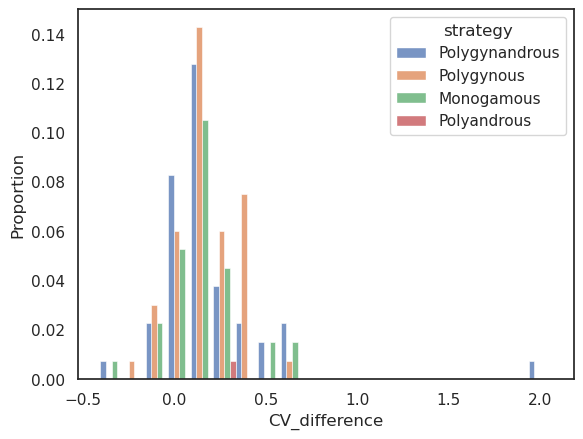

In [59]:
sns.histplot(mean_pi_df, x="CV_difference", hue="strategy", stat="proportion", multiple="dodge", bins=20)

In [60]:
mean_pi_df.loc[mean_pi_df.CV_difference >= 1]

chr_type,species,aut,chrX,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,CV_aut,CV_x,CV_difference,strategy
106,Macaca_sylvanus_ssp,35.721099,19.52448,0.000357,0.000195,0.546581,0.546581,Macaca_sylvanus,1.783211,3.842458,2.059247,Polygynandrous


In [61]:
filt_pi_df.loc[(filt_pi_df.species.isin(["Macaca_sylvanus_ssp"]))].groupby(["chrom"])[["pi"]].std()/filt_pi_df.loc[(filt_pi_df.species.isin(["Macaca_sylvanus_ssp"]))].groupby(["chrom"])[["pi"]].mean()

,pi
chrom,
NC_041754.1,1.996766
NC_041755.1,1.095857
NC_041756.1,1.888563
NC_041757.1,1.211120
NC_041758.1,1.282323
NC_041759.1,1.530721
NC_041760.1,1.936463
NC_041761.1,2.728488
NC_041762.1,1.232588


The CV for autosomes is slightly inflated due to adding different chromosomes together, but its not enough that I think its an issue.

In [85]:
df_l = []
fail_l = []
for s in all_pi_df.species.unique():
    s_df = filt_pi_df.loc[filt_pi_df.species == s]
    chrX_size = len(s_df.loc[s_df.chr_type == "chrX"])
    chrX_name = s_df.loc[s_df.chr_type == "chrX"].chrom.unique()
    sorted_sizes = s_df.loc[s_df.chr_type != "chrX"].groupby(["chrom"])[["species"]].count().reset_index().sort_values(by="species", ascending=False)
    similar_chrom_name = sorted_sizes.loc[sorted_sizes.species < chrX_size].chrom.iloc[0]
    try:
        chrX_df = s_df.loc[s_df.chr_type == "chrX"].copy()
        chrX_df["quartile"] = pd.qcut(chrX_df.pi, 4 , labels=[1, 2, 3, 4])
        aut_df = s_df.loc[s_df.chrom == similar_chrom_name].copy()
        aut_df["quartile"] = pd.qcut(aut_df.pi, 4 , labels=[1, 2, 3, 4])
    except:
        print(s)
        fail_l.append(s)
        continue
    chrX_df_group = chrX_df.groupby(["quartile"])[["pi"]].mean()
    aut_df_group = aut_df.groupby(["quartile"])[["pi"]].mean()
    out_df = pd.DataFrame({"quartiles": aut_df_group.index, "aut_quartile_means": aut_df_group.pi,
                          "chrX_quartile_means": chrX_df_group.pi})
    out_df["quartile_ratio"] = out_df["chrX_quartile_means"]/out_df["aut_quartile_means"]
    out_df["species"] = s
    df_l.append(out_df)
quartile_ratio_df = pd.concat(df_l)

/tmp/45939035/ipykernel_441633/3772023259.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chrX_df_group = chrX_df.groupby(["quartile"])[["pi"]].mean()
/tmp/45939035/ipykernel_441633/3772023259.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aut_df_group = aut_df.groupby(["quartile"])[["pi"]].mean()
/tmp/45939035/ipykernel_441633/3772023259.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chrX_df_group = chr

/tmp/45939035/ipykernel_441633/3772023259.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chrX_df_group = chrX_df.groupby(["quartile"])[["pi"]].mean()
/tmp/45939035/ipykernel_441633/3772023259.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aut_df_group = aut_df.groupby(["quartile"])[["pi"]].mean()
/tmp/45939035/ipykernel_441633/3772023259.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chrX_df_group = chr

/tmp/45939035/ipykernel_441633/3772023259.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chrX_df_group = chrX_df.groupby(["quartile"])[["pi"]].mean()
/tmp/45939035/ipykernel_441633/3772023259.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aut_df_group = aut_df.groupby(["quartile"])[["pi"]].mean()
/tmp/45939035/ipykernel_441633/3772023259.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chrX_df_group = chr

/tmp/45939035/ipykernel_441633/3772023259.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chrX_df_group = chrX_df.groupby(["quartile"])[["pi"]].mean()
/tmp/45939035/ipykernel_441633/3772023259.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aut_df_group = aut_df.groupby(["quartile"])[["pi"]].mean()
/tmp/45939035/ipykernel_441633/3772023259.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chrX_df_group = chr

/tmp/45939035/ipykernel_441633/3772023259.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chrX_df_group = chrX_df.groupby(["quartile"])[["pi"]].mean()
/tmp/45939035/ipykernel_441633/3772023259.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aut_df_group = aut_df.groupby(["quartile"])[["pi"]].mean()
/tmp/45939035/ipykernel_441633/3772023259.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chrX_df_group = chr

...

/tmp/45939035/ipykernel_441633/3772023259.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chrX_df_group = chrX_df.groupby(["quartile"])[["pi"]].mean()
/tmp/45939035/ipykernel_441633/3772023259.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aut_df_group = aut_df.groupby(["quartile"])[["pi"]].mean()
/tmp/45939035/ipykernel_441633/3772023259.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chrX_df_group = chr

Alouatta_palliata_ssp


/tmp/45939035/ipykernel_441633/3772023259.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chrX_df_group = chrX_df.groupby(["quartile"])[["pi"]].mean()
/tmp/45939035/ipykernel_441633/3772023259.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aut_df_group = aut_df.groupby(["quartile"])[["pi"]].mean()
/tmp/45939035/ipykernel_441633/3772023259.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chrX_df_group = chr

/tmp/45939035/ipykernel_441633/3772023259.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chrX_df_group = chrX_df.groupby(["quartile"])[["pi"]].mean()
/tmp/45939035/ipykernel_441633/3772023259.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aut_df_group = aut_df.groupby(["quartile"])[["pi"]].mean()
/tmp/45939035/ipykernel_441633/3772023259.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chrX_df_group = chr

/tmp/45939035/ipykernel_441633/3772023259.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chrX_df_group = chrX_df.groupby(["quartile"])[["pi"]].mean()
/tmp/45939035/ipykernel_441633/3772023259.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aut_df_group = aut_df.groupby(["quartile"])[["pi"]].mean()
/tmp/45939035/ipykernel_441633/3772023259.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chrX_df_group = chr

In [86]:
quartile_ratio_df["quartiles"]

quartile
1    1
2    2
3    3
4    4
1    1
    ..
4    4
1    1
2    2
3    3
4    4
Name: quartiles, Length: 760, dtype: category
Categories (4, int64): [1 < 2 < 3 < 4]

[Text(0.5, 0, 'X/A Ratio Quartiles'), Text(0, 0.5, 'X/A Ratio')]

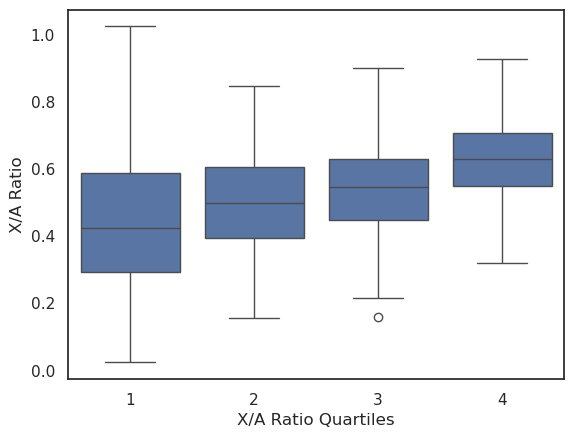

In [87]:
g = sns.boxplot(quartile_ratio_df, x="quartiles", y="quartile_ratio")
g.set(xlabel = "X/A Ratio Quartiles", ylabel="X/A Ratio")

In [88]:
quartile_ratio_df.loc[quartile_ratio_df.quartile_ratio > 0.9]

,quartiles,aut_quartile_means,chrX_quartile_means,quartile_ratio,species
quartile,,,,,
4,4,181.761148,166.582920,0.916494,Cacajao_calvus_ssp
3,3,170.007077,153.358434,0.902071,Aotus_griseimembra_ssp
4,4,252.424847,233.943284,0.926784,Aotus_griseimembra_ssp
1,1,65.064286,62.356250,0.958379,Hapalemur_meridionalis_ssp
1,1,21.493506,22.020576,1.024522,Indri_indri_ssp


In [89]:
quartile_ratio_df.loc[quartile_ratio_df.quartile_ratio < 0.1]

,quartiles,aut_quartile_means,chrX_quartile_means,quartile_ratio,species
quartile,,,,,
1,1,170.285073,14.715147,0.086415,Microcebus_murinus_ssp
1,1,198.067061,5.308140,0.026800,Lepilemur_septentrionalis_ssp
1,1,95.712515,4.903571,0.051232,Eulemur_coronatus_ssp
1,1,115.595238,5.672932,0.049076,Cheirogaleus_sibreei_ssp
1,1,25.922902,1.965021,0.075802,Pithecia_mittermeieri_ssp
1,1,63.758410,1.479167,0.023200,Cheracebus_torquatus_ssp
1,1,89.848797,3.922330,0.043655,Microcebus_tavaratra_ssp
1,1,26.039683,2.563464,0.098445,Mirza_zaza_ssp
1,1,288.787105,21.651214,0.074973,Eulemur_sanfordi_ssp


In [90]:
quartile_ratio_df.loc[quartile_ratio_df.species == "Gorilla_gorilla_ssp"]

,quartiles,aut_quartile_means,chrX_quartile_means,quartile_ratio,species
quartile,,,,,
1,1,102.887710,29.337540,0.285141,Gorilla_gorilla_ssp
2,2,170.069175,70.155464,0.412511,Gorilla_gorilla_ssp
3,3,217.872982,124.397650,0.570964,Gorilla_gorilla_ssp
4,4,296.124156,194.746715,0.657652,Gorilla_gorilla_ssp


In [91]:
quartile_ratio_df.loc[quartile_ratio_df.species == "Indri_indri_ssp"]

,quartiles,aut_quartile_means,chrX_quartile_means,quartile_ratio,species
quartile,,,,,
1,1,21.493506,22.020576,1.024522,Indri_indri_ssp
2,2,239.775862,102.546218,0.427675,Indri_indri_ssp
3,3,448.497817,205.162500,0.457444,Indri_indri_ssp
4,4,713.298701,364.325000,0.510761,Indri_indri_ssp


In [98]:
stats.ttest_rel(quartile_ratio_df.loc[quartile_ratio_df.quartiles == 1].quartile_ratio,
                quartile_ratio_df.loc[quartile_ratio_df.quartiles == 4].quartile_ratio)

TtestResult(statistic=-13.071218607295682, pvalue=3.117387460696484e-28, df=189)

In [100]:
for i in range(4):
    for j in range(i):
        print(i, j)
        results = stats.ttest_rel(quartile_ratio_df.loc[quartile_ratio_df.quartiles == i+1].quartile_ratio,
                quartile_ratio_df.loc[quartile_ratio_df.quartiles == j+1].quartile_ratio)
        print(results)

1 0
TtestResult(statistic=5.496891371895511, pvalue=1.2401640862272556e-07, df=189)
2 0
TtestResult(statistic=7.619813658439988, pvalue=1.19132665361087e-12, df=189)
2 1
TtestResult(statistic=8.787835507259468, pvalue=9.245757662796954e-16, df=189)
3 0
TtestResult(statistic=13.071218607295682, pvalue=3.117387460696484e-28, df=189)
3 1
TtestResult(statistic=15.738597378441801, pvalue=3.254982958714249e-36, df=189)
3 2
TtestResult(statistic=16.40597037160374, pvalue=3.443066601299136e-38, df=189)


<Axes: xlabel='quartile_ratio', ylabel='Count'>

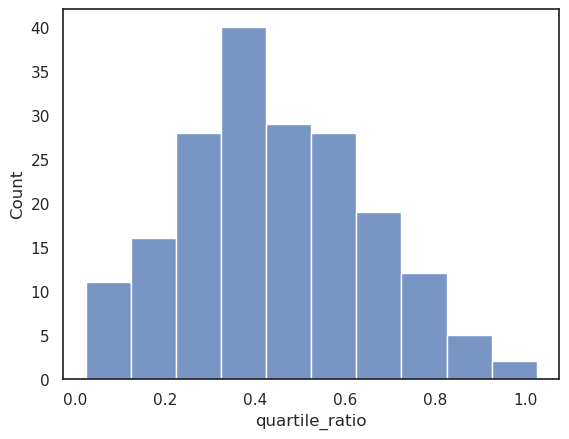

In [101]:
sns.histplot(quartile_ratio_df.loc[quartile_ratio_df.quartiles == 1], x="quartile_ratio")

In [73]:
# Implementation to check for streaks of low diversity.
for s in all_pi_df.species.unique()[:1]:
    s_df = all_pi_df.loc[all_pi_df.species == s]
    print(s)
    for c in s_df.chrom.unique():
        c_df = s_df.loc[(s_df.chrom == c) & (s_df.callable_frac >= 0.5)].copy()
        try:
            c_df["quartile"] = pd.qcut(c_df.pi, [0, 0.5, 1] , labels=False)
        except:
            print(c)
            continue
        k = 0
        k_list = []
        for q in c_df.quartile:
            if q == 0:
                k = k+1
            else:
                k = max(0, k-5)
            k_list.append(k)
        print(c, max(k_list))

Macaca_fascicularis_ssp
CP141361.1 98
CP141360.1 123
CP141359.1 65
CP141358.1 41
CP141357.1 66
CP141356.1 127
CP141355.1 81
CP141354.1 128
CP141353.1 95
CP141352.1 69
CP141351.1 51
CP141350.1 87
CP141349.1 115
CP141348.1 60
CP141347.1 92
CP141346.1 92
CP141345.1 26
CP141344.1 46
CP141343.1 28
CP141342.1 41
CP141341.1 81


In [103]:
s_df

,window_start,divergence,pi,chrom,window_end,callable_frac,chr_type,species
0,0,737.5,17.333333,NW_022680461.1,100000,0.75624,chrX,Semnopithecus_schistaceus_ssp
1,100000,790.5,13.333333,NW_022680461.1,200000,0.89528,chrX,Semnopithecus_schistaceus_ssp
2,200000,816.0,5.333333,NW_022680461.1,300000,0.87448,chrX,Semnopithecus_schistaceus_ssp
3,300000,1036.0,2.000000,NW_022680461.1,400000,0.90270,chrX,Semnopithecus_schistaceus_ssp
4,400000,861.5,3.333333,NW_022680461.1,500000,0.86684,chrX,Semnopithecus_schistaceus_ssp
...,...,...,...,...,...,...,...,...
27929,77900000,1591.5,155.500000,NW_022681474.1,78000000,0.77192,aut,Semnopithecus_schistaceus_ssp
27930,78000000,1518.0,54.666667,NW_022681474.1,78100000,0.96157,aut,Semnopithecus_schistaceus_ssp
27931,78100000,1640.5,148.000000,NW_022681474.1,78200000,0.96095,aut,Semnopithecus_schistaceus_ssp
27932,78200000,1590.5,245.666667,NW_022681474.1,78300000,0.94313,aut,Semnopithecus_schistaceus_ssp
